# Load Katelyn W&B Runs

This notebook loads runs from the `karella/hippy2d` W&B project whose run name contains `katelyn`, for example `esnet18-katelyn-flips`.

In [1]:
from pathlib import Path
import json
import os

import pandas as pd
import wandb

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

## Configure W&B

The training script uses `karella/hippy2d`, so those are the defaults here. If `~/.wandb_key.json` exists, the notebook will load `WANDB_API_KEY` and `WANDB_HOST` from it.

In [2]:
ENTITY = os.environ.get("WANDB_ENTITY", "karella")
PROJECT = os.environ.get("WANDB_PROJECT", "hippy2d")
NAME_CONTAINS = "katelyn"

wandb_key_path = Path.home() / ".wandb_key.json"
if wandb_key_path.exists():
    with wandb_key_path.open() as f:
        wandb_config = json.load(f)
    os.environ.setdefault("WANDB_API_KEY", wandb_config.get("WANDB_API_KEY", ""))
    os.environ.setdefault("WANDB_HOST", wandb_config.get("WANDB_HOST", ""))

api = wandb.Api(timeout=120)
project_path = f"{ENTITY}/{PROJECT}"
project_path

'karella/hippy2d'

## Load Matching Runs

In [3]:
def run_matches(run, text=NAME_CONTAINS):
    text = text.casefold()
    candidates = [run.name or "", run.id or "", getattr(run, "group", "") or ""]
    return any(text in candidate.casefold() for candidate in candidates)


all_runs = list(api.runs(project_path, order="-created_at"))
runs = [run for run in all_runs if run_matches(run)]

print(f"Loaded {len(runs)} matching runs out of {len(all_runs)} runs from {project_path}.")
[run.name for run in runs[:20]]

Loaded 120 matching runs out of 2332 runs from karella/hippy2d.


['resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images-flipsrot',
 'resnet18-katelyn-images',
 'resnet18-katelyn-images',
 'resnet18-katelyn-images',
 'resnet18-katelyn-images',
 'resnet18-katelyn-images']

## Summary Table

In [4]:
def flatten_dict(d, prefix=""):
    rows = {}
    for key, value in d.items():
        if key.startswith("_"):
            continue
        full_key = f"{prefix}.{key}" if prefix else key
        if isinstance(value, dict):
            rows.update(flatten_dict(value, full_key))
        else:
            rows[full_key] = value
    return rows


def run_record(run):
    summary = flatten_dict(dict(run.summary))
    config = flatten_dict(dict(run.config))
    record = {
        "name": run.name,
        "id": run.id,
        "state": run.state,
        "created_at": run.created_at,
        "url": run.url,
        "group": getattr(run, "group", None),
        "job_type": getattr(run, "job_type", None),
        "tags": ", ".join(run.tags or []),
    }
    for key, value in summary.items():
        record[f"summary.{key}"] = value
    for key, value in config.items():
        record[f"config.{key}"] = value
    return record


runs_df = pd.DataFrame([run_record(run) for run in runs])
if not runs_df.empty:
    runs_df = runs_df.sort_values("created_at", ascending=False).reset_index(drop=True)

runs_df

,name,id,state,created_at,url,group,job_type,tags,summary.epoch,summary.gradients/model.resnet.bn1.bias,summary.gradients/model.resnet.bn1.weight,summary.gradients/model.resnet.conv1.weight,summary.gradients/model.resnet.fc.bias,summary.gradients/model.resnet.fc.weight,summary.gradients/model.resnet.layer1.0.bn1.bias,summary.gradients/model.resnet.layer1.0.bn1.weight,summary.gradients/model.resnet.layer1.0.bn2.bias,summary.gradients/model.resnet.layer1.0.bn2.weight,summary.gradients/model.resnet.layer1.0.conv1.weight,summary.gradients/model.resnet.layer1.0.conv2.weight,summary.gradients/model.resnet.layer1.1.bn1.bias,summary.gradients/model.resnet.layer1.1.bn1.weight,summary.gradients/model.resnet.layer1.1.bn2.bias,summary.gradients/model.resnet.layer1.1.bn2.weight,summary.gradients/model.resnet.layer1.1.conv1.weight,summary.gradients/model.resnet.layer1.1.conv2.weight,summary.gradients/model.resnet.layer2.0.bn1.bias,summary.gradients/model.resnet.layer2.0.bn1.weight,summary.gradients/model.resnet.layer2.0.bn2.bias,summary.gradients/model.resnet.layer2.0.bn2.weight,summary.gradients/model.resnet.layer2.0.conv1.weight,summary.gradients/model.resnet.layer2.0.conv2.weight,summary.gradients/model.resnet.layer2.0.downsample.0.weight,summary.gradients/model.resnet.layer2.0.downsample.1.bias,summary.gradients/model.resnet.layer2.0.downsample.1.weight,summary.gradients/model.resnet.layer2.1.bn1.bias,summary.gradients/model.resnet.layer2.1.bn1.weight,summary.gradients/model.resnet.layer2.1.bn2.bias,summary.gradients/model.resnet.layer2.1.bn2.weight,summary.gradients/model.resnet.layer2.1.conv1.weight,summary.gradients/model.resnet.layer2.1.conv2.weight,summary.gradients/model.resnet.layer3.0.bn1.bias,summary.gradients/model.resnet.layer3.0.bn1.weight,summary.gradients/model.resnet.layer3.0.bn2.bias,summary.gradients/model.resnet.layer3.0.bn2.weight,summary.gradients/model.resnet.layer3.0.conv1.weight,summary.gradients/model.resnet.layer3.0.conv2.weight,summary.gradients/model.resnet.layer3.0.downsample.0.weight,summary.gradients/model.resnet.layer3.0.downsample.1.bias,summary.gradients/model.resnet.layer3.0.downsample.1.weight,summary.gradients/model.resnet.layer3.1.bn1.bias,summary.gradients/model.resnet.layer3.1.bn1.weight,summary.gradients/model.resnet.layer3.1.bn2.bias,summary.gradients/model.resnet.layer3.1.bn2.weight,summary.gradients/model.resnet.layer3.1.conv1.weight,summary.gradients/model.resnet.layer3.1.conv2.weight,summary.gradients/model.resnet.layer4.0.bn1.bias,summary.gradients/model.resnet.layer4.0.bn1.weight,summary.gradients/model.resnet.layer4.0.bn2.bias,summary.gradients/model.resnet.layer4.0.bn2.weight,...,config.m_param.layer,config.m_param.block_types,config.m_param.norm1_layer,config.m_param.norm2_layer,config.m_param.disable_act1,config.m_param.channels_masking,config.m_param.default_layer_kwargs.mag_func,config.m_param.default_layer_kwargs.max_order,config.m_param.default_layer_kwargs.phase_func,config.m_param.default_layer_kwargs.pre_norm_func,config.optimizer_hparams.weight_decay,summary.gradients/model.layer1.1.conv1.moment_layer.weights,summary.gradients/model.layer1.1.conv2.weight,summary.gradients/model.layer2.2.conv1.moment_layer.weights,summary.gradients/model.layer2.2.conv2.weight,summary.gradients/model.layer3.2.conv1.moment_layer.weights,summary.gradients/model.layer3.2.conv2.weight,config.m_param.norm,config.m_param.default_layer_kwargs.output_features,config.m_param.default_layer_kwargs.norm_per_inv_type,summary.gradients/model.blocks.0.0.act.merging.submodule_1.bias,summary.gradients/model.blocks.0.0.conv.bias,summary.gradients/model.blocks.0.0.conv.weights,summary.gradients/model.blocks.0.0.norm.merging.submodule_0.batch_norm_[1].bias,summary.gradients/model.blocks.0.0.norm.merging.submodule_0.batch_norm_[1].weight,summary.gradients/model.blocks.0.0.norm.merging.submodule_1.irreps_weight,summary.gradients/model.blocks.1.0.act.merging.submodule_1.bias,summary.gradients/model.blocks.1.0.conv.bias,

## Pull Histories

Set `HISTORY_KEYS` to the metrics you want. Leaving it as `None` asks W&B for every logged scalar column it returns through the public history API.

In [5]:
HISTORY_KEYS = None
HISTORY_SAMPLES = 100_000


def load_history(run, keys=HISTORY_KEYS, samples=HISTORY_SAMPLES):
    history = run.history(keys=keys, samples=samples, pandas=True)
    history.insert(0, "run_name", run.name)
    history.insert(1, "run_id", run.id)
    return history


histories = {run.name: load_history(run) for run in runs}
history_df = pd.concat(histories.values(), ignore_index=True) if histories else pd.DataFrame()

history_df

,run_name,run_id,trainer/global_step,model/total_mb,model/params_mb,_step,lr-AdamW,test_top5_acc,val_loss,model/params_trainable,val_acc,train_acc,test_acc,test_rci_sim_n4,val_top5_acc,_runtime,epoch,test_loss,train_top5_acc,test_rci_sim_min_n4,_timestamp,test_rci_norm_max_n4,model/buffers_mb,test_rci_norm_n4,train_epoch_time,model/params_total,train_loss,model/params_non_trainable,gradients/model.resnet.layer2.1.bn1.bias,gradients/model.resnet.layer1.1.conv2.weight,gradients/model.resnet.layer3.0.downsample.1.weight,gradients/model.resnet.layer4.0.conv2.weight,gradients/model.resnet.layer4.0.bn2.bias,gradients/model.resnet.layer1.1.bn2.bias,gradients/model.resnet.layer2.1.conv2.weight,gradients/model.resnet.layer2.1.conv1.weight,gradients/model.resnet.layer2.0.conv1.weight,gradients/model.resnet.layer2.0.conv2.weight,gradients/model.resnet.layer2.0.bn1.weight,gradients/model.resnet.layer2.1.bn2.weight,gradients/model.resnet.layer3.0.conv1.weight,gradients/model.resnet.layer4.0.bn2.weight,gradients/model.resnet.layer4.1.conv1.weight,gradients/model.resnet.layer4.1.bn1.weight,gradients/model.resnet.layer2.0.downsample.0.weight,gradients/model.resnet.layer2.0.downsample.1.bias,gradients/model.resnet.layer1.1.bn1.bias,gradients/model.resnet.layer1.0.bn1.bias,gradients/model.resnet.layer3.0.downsample.0.weight,gradients/model.resnet.layer1.1.bn1.weight,gradients/model.resnet.layer1.0.bn2.weight,gradients/model.resnet.layer2.1.bn1.weight,gradients/model.resnet.bn1.weight,gradients/model.resnet.bn1.bias,gradients/model.resnet.layer2.0.bn2.bias,gradients/model.resnet.layer4.0.bn1.weight,gradients/model.resnet.layer4.1.bn2.weight,gradients/model.resnet.layer1.0.bn1.weight,gradients/model.resnet.fc.weight,gradients/model.resnet.layer4.0.downsample.1.weight,...,gradients/model.bn1.bias,gradients/model.fc.weight,gradients/model.layer4.0.bn1.bias,gradients/model.conv1.1.weight,gradients/model.layer3.0.downsample.2.weight,gradients/model.layer2.0.downsample.1.weight,gradients/model.layer2.0.downsample.2.weight,gradients/model.layer4.0.bn2.bias,gradients/model.layer3.0.downsample.1.weight,gradients/model.layer4.0.bn2.weight,gradients/model.layer1.0.bn2.weight,gradients/model.layer1.0.identity.bias,gradients/model.layer3.1.conv1.moment_layer.weights,gradients/model.layer2.0.conv1.moment_layer.weights,gradients/model.layer1.0.conv1.moment_layer.weights,gradients/model.layer3.1.conv2.weight,gradients/model.layer2.0.identity.weight,gradients/model.layer2.1.conv1.moment_layer.weights,gradients/model.layer2.1.conv2.weight,gradients/model.layer3.0.identity.bias,gradients/model.layer2.0.identity.bias,gradients/model.layer3.0.conv1.moment_layer.weights,gradients/model.layer3.0.identity.weight,gradients/model.layer1.0.identity.weight,gradients/model.blocks.1.1.norm.merging.submodule_1.irreps_weight,gradients/model.blocks.0.0.conv.bias,gradients/model.blocks.1.0.conv.weights,gradients/model.blocks.1.1.conv.weights,gradients/model.blocks.0.0.norm.merging.submodule_0.batch_norm_[1].bias,gradients/model.stem.act.merging.submodule_1.bias,gradients/model.blocks.2.1.norm.merging.submodule_0.batch_norm_[1].weight,gradients/model.blocks.2.0.norm.merging.submodule_0.batch_norm_[1].bias,gradients/model.stem.norm.merging.submodule_0.batch_norm_[1].weight,gradients/model.blocks.2.0.conv.bias,gradients/model.blocks.0.0.norm.merging.submodule_1.irreps_weight,gradients/model.blocks.1.1.norm.merging.submodule_0.batch_norm_[1].bias,gradients/model.blocks.0.0.norm.merging.submodule_0.batch_norm_[1].weight,gradients/model.blocks.1.1.conv.bias,gradients/model.blocks.0.0.conv.weights,gradients/model.blocks.1.0.act.merging.submodule_1.bias,gradients/model.blocks.2.0.norm.merging.submodule_1.irreps_weight,gradients/model.blocks.1.1.norm.merging.submodule_0.batch_norm_[1].weight,gradients/model.blocks.1.0.conv.bias,gradients/model.stem.norm.merging.submodule_0.batch_norm_[1].bias,gradients/model.blocks.1.0.norm.merging.submodule_0.batch_norm_[1].weight,gradients/model.blocks

## Quick Metric View

In [6]:
metric_columns = [
    column
    for column in history_df.columns
    if column not in {"run_name", "run_id", "_step", "_runtime", "_timestamp"}
    and pd.api.types.is_numeric_dtype(history_df[column])
]

metric_columns[:50]

['trainer/global_step',
 'model/total_mb',
 'model/params_mb',
 'lr-AdamW',
 'test_top5_acc',
 'val_loss',
 'model/params_trainable',
 'val_acc',
 'train_acc',
 'test_acc',
 'test_rci_sim_n4',
 'val_top5_acc',
 'epoch',
 'test_loss',
 'train_top5_acc',
 'test_rci_sim_min_n4',
 'test_rci_norm_max_n4',
 'model/buffers_mb',
 'test_rci_norm_n4',
 'train_epoch_time',
 'model/params_total',
 'train_loss',
 'model/params_non_trainable']

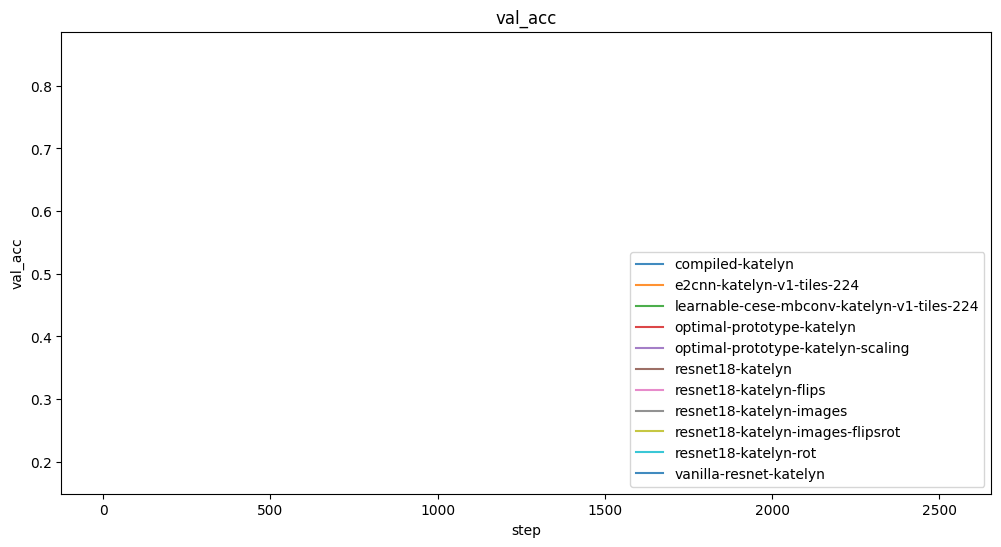

In [7]:
import matplotlib.pyplot as plt

METRIC = "val_acc" if "val_acc" in metric_columns else (metric_columns[0] if metric_columns else None)

if METRIC is None:
    print("No numeric history metrics found.")
else:
    fig, ax = plt.subplots(figsize=(12, 6))
    for run_name, run_history in history_df.groupby("run_name"):
        run_history.plot(x="_step", y=METRIC, ax=ax, label=run_name, alpha=0.85)
    ax.set_title(METRIC)
    ax.set_xlabel("step")
    ax.set_ylabel(METRIC)
    ax.legend(loc="best")

## Compact Run DataFrame

In [8]:
def config_value(config, *path, default=None):
    value = config
    for key in path:
        if not isinstance(value, dict) or key not in value:
            return default
        value = value[key]
    return value


def model_from_name(run_name):
    return run_name.split("-katelyn", 1)[0] if "-katelyn" in run_name else run_name


def summary_value(summary, *keys, default=None):
    for key in keys:
        if key in summary:
            return summary[key]
    return default


def image_source(run):
    candidates = [
        run.name or "",
        config_value(run.config, "run_name", default="") or "",
        config_value(run.config, "d_hparams", "train_dir", default="") or "",
        config_value(run.config, "d_hparams", "valid_dir", default="") or "",
        config_value(run.config, "d_hparams", "test_dir", default="") or "",
    ]
    text = " ".join(str(candidate).casefold() for candidate in candidates)
    return "whole images" if "images" in text or "v1-images" in text else "crops"


def train_fraction(run):
    value = config_value(run.config, "d_hparams", "train_data_fraction")
    if value is not None:
        return value
    return 1.0 if image_source(run) == "whole images" else None


df = pd.DataFrame(
    [
        {
            "train_data_fraction": train_fraction(run),
            "name": run.name,
            "test_acc": summary_value(run.summary, "test_acc", "test/acc", "test_accuracy"),
            "image_source": image_source(run),
            "model": config_value(run.config, "model_name", default=model_from_name(run.name)),
            "aug_flips": config_value(
                run.config,
                "d_hparams",
                "aug_flips",
                default=False,
            ),
            "aug_rot": config_value(
                run.config,
                "d_hparams",
                "aug_rot",
                default=False,
            ),
        }
        for run in runs
    ],
    columns=["train_data_fraction", "name", "test_acc", "image_source", "model", "aug_flips", "aug_rot"],
)

if not df.empty:
    df = df.sort_values(["image_source", "train_data_fraction", "model", "name"], na_position="last").reset_index(drop=True)

df

,train_data_fraction,name,test_acc,image_source,model,aug_flips,aug_rot
0,0.001,optimal-prototype-katelyn,0.430581,crops,PrototypeOptimal,True,False
1,0.001,optimal-prototype-katelyn,0.444858,crops,PrototypeOptimal,True,False
2,0.001,optimal-prototype-katelyn,0.422201,crops,PrototypeOptimal,True,False
3,0.001,optimal-prototype-katelyn,0.449048,crops,PrototypeOptimal,False,True
4,0.001,optimal-prototype-katelyn,0.460861,crops,PrototypeOptimal,False,True
...,...,...,...,...,...,...,...
115,1.000,resnet18-katelyn-images,0.843851,whole images,Resnet18,False,True
116,1.000,resnet18-katelyn-images,0.853947,whole images,Resnet18,False,True
117,1.000,resnet18-katelyn-images-flipsrot,0.853237,whole images,Resnet18,True,True
118,1.000,resnet18-katelyn-images-flipsrot,0.859071,whole images,Resnet18,True,True


## Train Fraction by Model: Crops vs Whole Images

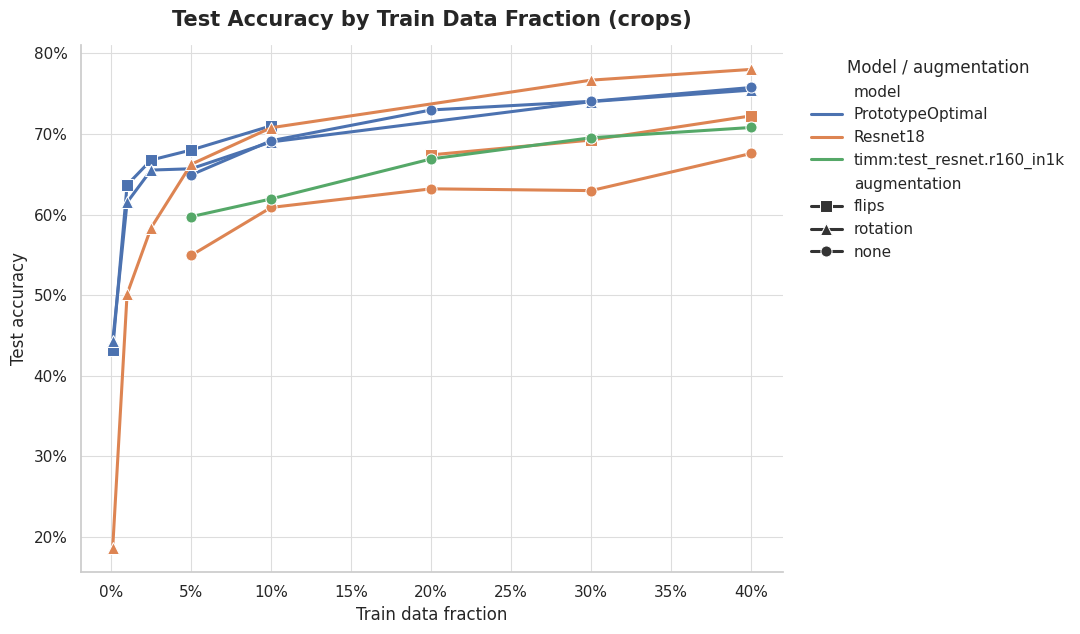

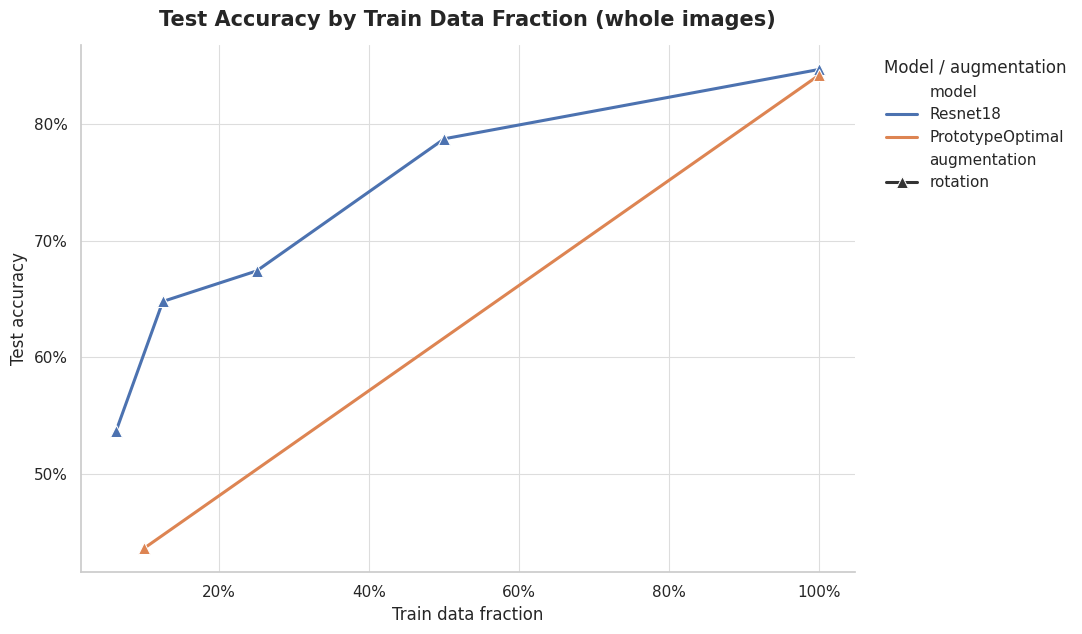

In [9]:
import seaborn as sns

plot_df = df.dropna(subset=["train_data_fraction", "model", "test_acc"]).copy()
plot_df["train_data_fraction"] = pd.to_numeric(plot_df["train_data_fraction"], errors="coerce")
plot_df["test_acc"] = pd.to_numeric(plot_df["test_acc"], errors="coerce")
plot_df["augmentation"] = "none"
plot_df.loc[plot_df["aug_flips"].fillna(False).astype(bool), "augmentation"] = "flips"
plot_df.loc[plot_df["aug_rot"].fillna(False).astype(bool), "augmentation"] = "rotation"
plot_df = plot_df.dropna(subset=["train_data_fraction", "model", "test_acc"])

def plot_train_fraction_by_model(data, image_source, ax=None):
    source_df = data[data["image_source"] == image_source].sort_values("train_data_fraction")
    if source_df.empty:
        print(f"No rows for {image_source} after dropping NA train_data_fraction/model/test_acc values.")
        return None

    if ax is None:
        _, ax = plt.subplots(figsize=(11, 6.5))

    sns.lineplot(
        data=source_df,
        x="train_data_fraction",
        y="test_acc",
        hue="model",
        style="augmentation",
        markers={"none": "o", "flips": "s", "rotation": "^"},
        dashes=False,
        linewidth=2.2,
        markersize=8,
        errorbar=None,
        ax=ax,
    )
    ax.set_title(f"Test Accuracy by Train Data Fraction ({image_source})", fontsize=15, weight="bold", pad=14)
    ax.set_xlabel("Train data fraction")
    ax.set_ylabel("Test accuracy")
    ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
    ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")
    ax.grid(True, color="#dddddd", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Model / augmentation", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    return ax


if plot_df.empty:
    print("No rows left after dropping NA train_data_fraction/model/test_acc values.")
else:
    sns.set_theme(style="whitegrid", context="notebook")
    for source in ["crops", "whole images"]:
        ax = plot_train_fraction_by_model(plot_df, source)
        if ax is not None:
            ax.figure.tight_layout()

In [10]:
plot_df.loc[plot_df['image_source'] == "whole images"].groupby(["model", "train_data_fraction", "augmentation"])["test_acc"].agg(["mean", "std", "count"]   )

mean       std  count
model            train_data_fraction augmentation                           
PrototypeOptimal 0.1000              rotation      0.436003  0.132977      2
                 1.0000              rotation      0.842127       NaN      1
Resnet18         0.0625              rotation      0.536213  0.007223      6
                 0.1250              rotation      0.647744  0.006457      6
                 0.2500              rotation      0.673921  0.016684      6
                 0.5000              rotation      0.787270  0.005641      6
                 1.0000              rotation      0.846800  0.008204      8

In [14]:
runs_df.loc[runs_df['state'] == 'finished']

,name,id,state,created_at,url,group,job_type,tags,summary.epoch,summary.gradients/model.resnet.bn1.bias,summary.gradients/model.resnet.bn1.weight,summary.gradients/model.resnet.conv1.weight,summary.gradients/model.resnet.fc.bias,summary.gradients/model.resnet.fc.weight,summary.gradients/model.resnet.layer1.0.bn1.bias,summary.gradients/model.resnet.layer1.0.bn1.weight,summary.gradients/model.resnet.layer1.0.bn2.bias,summary.gradients/model.resnet.layer1.0.bn2.weight,summary.gradients/model.resnet.layer1.0.conv1.weight,summary.gradients/model.resnet.layer1.0.conv2.weight,summary.gradients/model.resnet.layer1.1.bn1.bias,summary.gradients/model.resnet.layer1.1.bn1.weight,summary.gradients/model.resnet.layer1.1.bn2.bias,summary.gradients/model.resnet.layer1.1.bn2.weight,summary.gradients/model.resnet.layer1.1.conv1.weight,summary.gradients/model.resnet.layer1.1.conv2.weight,summary.gradients/model.resnet.layer2.0.bn1.bias,summary.gradients/model.resnet.layer2.0.bn1.weight,summary.gradients/model.resnet.layer2.0.bn2.bias,summary.gradients/model.resnet.layer2.0.bn2.weight,summary.gradients/model.resnet.layer2.0.conv1.weight,summary.gradients/model.resnet.layer2.0.conv2.weight,summary.gradients/model.resnet.layer2.0.downsample.0.weight,summary.gradients/model.resnet.layer2.0.downsample.1.bias,summary.gradients/model.resnet.layer2.0.downsample.1.weight,summary.gradients/model.resnet.layer2.1.bn1.bias,summary.gradients/model.resnet.layer2.1.bn1.weight,summary.gradients/model.resnet.layer2.1.bn2.bias,summary.gradients/model.resnet.layer2.1.bn2.weight,summary.gradients/model.resnet.layer2.1.conv1.weight,summary.gradients/model.resnet.layer2.1.conv2.weight,summary.gradients/model.resnet.layer3.0.bn1.bias,summary.gradients/model.resnet.layer3.0.bn1.weight,summary.gradients/model.resnet.layer3.0.bn2.bias,summary.gradients/model.resnet.layer3.0.bn2.weight,summary.gradients/model.resnet.layer3.0.conv1.weight,summary.gradients/model.resnet.layer3.0.conv2.weight,summary.gradients/model.resnet.layer3.0.downsample.0.weight,summary.gradients/model.resnet.layer3.0.downsample.1.bias,summary.gradients/model.resnet.layer3.0.downsample.1.weight,summary.gradients/model.resnet.layer3.1.bn1.bias,summary.gradients/model.resnet.layer3.1.bn1.weight,summary.gradients/model.resnet.layer3.1.bn2.bias,summary.gradients/model.resnet.layer3.1.bn2.weight,summary.gradients/model.resnet.layer3.1.conv1.weight,summary.gradients/model.resnet.layer3.1.conv2.weight,summary.gradients/model.resnet.layer4.0.bn1.bias,summary.gradients/model.resnet.layer4.0.bn1.weight,summary.gradients/model.resnet.layer4.0.bn2.bias,summary.gradients/model.resnet.layer4.0.bn2.weight,...,config.m_param.layer,config.m_param.block_types,config.m_param.norm1_layer,config.m_param.norm2_layer,config.m_param.disable_act1,config.m_param.channels_masking,config.m_param.default_layer_kwargs.mag_func,config.m_param.default_layer_kwargs.max_order,config.m_param.default_layer_kwargs.phase_func,config.m_param.default_layer_kwargs.pre_norm_func,config.optimizer_hparams.weight_decay,summary.gradients/model.layer1.1.conv1.moment_layer.weights,summary.gradients/model.layer1.1.conv2.weight,summary.gradients/model.layer2.2.conv1.moment_layer.weights,summary.gradients/model.layer2.2.conv2.weight,summary.gradients/model.layer3.2.conv1.moment_layer.weights,summary.gradients/model.layer3.2.conv2.weight,config.m_param.norm,config.m_param.default_layer_kwargs.output_features,config.m_param.default_layer_kwargs.norm_per_inv_type,summary.gradients/model.blocks.0.0.act.merging.submodule_1.bias,summary.gradients/model.blocks.0.0.conv.bias,summary.gradients/model.blocks.0.0.conv.weights,summary.gradients/model.blocks.0.0.norm.merging.submodule_0.batch_norm_[1].bias,summary.gradients/model.blocks.0.0.norm.merging.submodule_0.batch_norm_[1].weight,summary.gradients/model.blocks.0.0.norm.merging.submodule_1.irreps_weight,summary.gradients/model.blocks.1.0.act.merging.submodule_1.bias,summary.gradients/model.blocks.1.0.conv.bias,